In [1]:
"""Insurance companies make pricing decisions based on historical claims experience. 
The more recent the claims experience, the more predictive it may be of future losses.
 In the case of many large claims however, the exact cost is not known at the time of the accident. 
In fact, some cases take years to develop and settle. 
Companies sometimes learn that a claim is large several years after the accident took place.

Your Underwriting Director believes it is possible to predict the ultimate value of individual claims
 well in advance by using FNOL (First Notification Of Loss) characteristics. 
 This is the information recorded when the claim is first notified.
 If so, it would allow the company to know about future costs earlier 
 and this information could be used to make better pricing decisions.
 
 You are given a historical dataset of a particular type of claim - head-on collisions - and are also
 told their individual current estimated values (labelled Incurred).
 (Given these claims are now a few years old, you can assume the incurred values are equal to the cost
 at which the claims will finally settle). 
 
 Task breakdown:
 1) Using this data, build a model to predict the ultimate individual claim amounts"""

'Insurance companies make pricing decisions based on historical claims experience. \nThe more recent the claims experience, the more predictive it may be of future losses.\n In the case of many large claims however, the exact cost is not known at the time of the accident. \nIn fact, some cases take years to develop and settle. \nCompanies sometimes learn that a claim is large several years after the accident took place.\n\nYour Underwriting Director believes it is possible to predict the ultimate value of individual claims\n well in advance by using FNOL (First Notification Of Loss) characteristics. \n This is the information recorded when the claim is first notified.\n If so, it would allow the company to know about future costs earlier \n and this information could be used to make better pricing decisions.\n \n You are given a historical dataset of a particular type of claim - head-on collisions - and are also\n told their individual current estimated values (labelled Incurred).\n (G

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils import (
    preprocess_data, extract_features_and_target, plot_temporal_split, plot_target_histograms,
    plot_pred_vs_actual, plot_vs_actual_pairs, plot_intervals, cast_cat_to_str, make_pools, cb_params,
    encode_sets, brier_pair, apply_lda
)

df = pd.read_excel('Data_Scientist_Interview_Task.xlsx', engine='openpyxl')

df = df.sample(frac=0.02)


df = preprocess_data(df)
target_name = "incurred_clean"
df_copy = df.copy()


notifier
location_of_incident
weather_conditions
incurred
cappedincurred
Injury columns detected: ['tp_injury_whiplash', 'tp_injury_traumatic', 'tp_injury_fatality', 'tp_injury_unclear', 'tp_injury_nk']
Added injury-derived feature columns (subset):
['injury_details_present', 'injury_any_flag', 'injury_count', 'injury_known_flag', 'injury_unknown_flag', 'injury_known_ratio', 'injury_severity_score_linear', 'injury_severity_score_rss', 'injury_diversity', 'injury_fatal_flag', 'injury_traumatic_flag', 'vehicle_mobile_x_injury_sev', 'main_driver_x_injury_sev', 'ph_considered_tp_at_fault_x_injury_sev']


In [2]:
import pandas as pd
import numpy as np
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, TweedieRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, brier_score_loss
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis



model_defs = [
    ("DummyMean", DummyRegressor(strategy='mean')),
    ("GLM_Tweedie_p1.5", TweedieRegressor(power=1.5, alpha=0.0, max_iter=2000)),
    ("GLM_Gamma_p2.0", TweedieRegressor(power=2.0, alpha=0.0, max_iter=2000)),
    ("Linear", LinearRegression()),
    ("DecisionTree", DecisionTreeRegressor(max_depth=8, random_state=42)),
    ("RandomForest", RandomForestRegressor(n_estimators=300, max_depth=12, n_jobs=-1, random_state=42)),
    ("GradientBoosting", GradientBoostingRegressor(random_state=42)),
]

test_sizes = [0.05, 0.15, 0.25]
adv_results = []
for test_size in test_sizes:
    X_train, X_val, X_test, y_train, y_val, y_test = extract_features_and_target(
        df_copy, drop_missing_target=True, split=True, target=target_name, val_size=0.2, test_size=test_size
    )

    # GLMs need positive targets
    y_train_pos = y_train.clip(lower=1e-6)
    y_val_pos = y_val.clip(lower=1e-6)
    y_test_pos = y_test.clip(lower=1e-6)

    # encode + LDA
    X_train_enc, X_val_enc, X_test_enc = encode_sets(X_train.copy(), X_val.copy(), X_test.copy())
    X_train_lda, X_val_lda, X_test_lda = apply_lda(X_train_enc, X_val_enc, X_test_enc, y_train)

    for name, model in model_defs:
        if name.startswith("GLM_"):
            model.fit(X_train_lda, y_train_pos)
            y_val_pred = model.predict(X_val_lda)
            y_test_pred = model.predict(X_test_lda)
        else:
            model.fit(X_train_lda, y_train)
            y_val_pred = model.predict(X_val_lda)
            y_test_pred = model.predict(X_test_lda)

        val_brier = brier_pair(y_train, y_val, y_val_pred)
        test_brier = brier_pair(y_train, y_test, y_test_pred)

        adv_results.append({
            'test_size': test_size,
            'model': name + '_LDA',
            'val_r2': r2_score(y_val, y_val_pred),
            'test_r2': r2_score(y_test, y_test_pred),
            'val_rmse': mean_squared_error(y_val, y_val_pred),
            'test_rmse': mean_squared_error(y_test, y_test_pred),
            'val_mae': mean_absolute_error(y_val, y_val_pred),
            'test_mae': mean_absolute_error(y_test, y_test_pred),
            'val_brier': val_brier,
            'test_brier': test_brier,
            'y_test_actual': y_test.values,
            'y_test_pred': y_test_pred,
        })

adv_df = pd.DataFrame(adv_results)

print("\nFull results for all test sizes sorted by test_r2:")
print(adv_df.iloc[:, :-2].sort_values(['test_size', 'test_r2'], ascending=[True, False]).to_string(index=False))

adv_df_015 = adv_df[adv_df['test_size'] == 0.15]
best_row = adv_df_015.loc[adv_df_015['test_r2'].idxmax()]
print("\nBest baseline model (test_size=0.15):")
print(best_row[['model','test_size','test_r2','test_rmse','test_mae','test_brier']])

baseline_test_actual = best_row['y_test_actual']
baseline_test_pred = best_row['y_test_pred']

baseline_results = adv_df[adv_df["model"] == best_row.model]
baseline_results.iloc[:, :-2]


Full results for all test sizes sorted by test_r2:
 test_size                model      val_r2       test_r2     val_rmse    test_rmse       val_mae     test_mae  val_brier  test_brier
      0.05        DummyMean_LDA   -3.422061 -1.530644e+01 3.073799e+08 3.479467e+08  16283.792009 1.807232e+04   0.403740    0.188893
      0.05     RandomForest_LDA  -22.115701 -2.719335e+02 1.606785e+09 5.823854e+09  16382.378886 3.631386e+04   0.419827    0.209110
      0.05           Linear_LDA  -35.598501 -2.821265e+02 2.543982e+09 6.041351e+09  38072.499336 5.342853e+04   0.405319    0.209647
      0.05 GradientBoosting_LDA  -32.014494 -3.178692e+02 2.294856e+09 6.804028e+09  19815.107622 3.932799e+04   0.419514    0.211493
      0.05   GLM_Gamma_p2.0_LDA -524.847058 -4.466978e+02 3.655192e+10 9.552972e+09  57958.957139 4.843670e+04   0.355177    0.218520
      0.05     DecisionTree_LDA  -43.639015 -5.579193e+02 3.102883e+09 1.192622e+10  20319.044218 5.184844e+04   0.421779    0.223052
      0.05

,test_size,model,val_r2,test_r2,val_rmse,test_rmse,val_mae,test_mae,val_brier,test_brier
4,0.05,DecisionTree_LDA,-43.639015,-557.919307,3.102883e+09,1.192622e+10,20319.044218,51848.442857,0.421779,0.223052
11,0.15,DecisionTree_LDA,-13.883822,-0.537095,3.391843e+09,1.099767e+08,21248.800000,5557.803922,0.520283,0.433505
18,0.25,DecisionTree_LDA,-21.519432,-69.436698,9.069988e+09,4.094925e+09,51702.032353,21129.676786,0.591927,0.409123



Comparison of Baseline vs CatBoost for all test sizes:
 Test Size         Model     Type   Test R2    Test RMSE     Test MAE  Test Brier
      0.05 DummyMean_LDA Baseline -0.340929 4.398713e+07  6323.177305    0.273851
      0.05      CatBoost CatBoost  0.485167 1.688829e+07  3549.414522    0.283132
      0.15 DummyMean_LDA Baseline -0.190754 4.353054e+07  6024.425926    0.404808
      0.15      CatBoost CatBoost -0.975295 7.221110e+07  6623.052945    0.402904
      0.25 DummyMean_LDA Baseline -0.028011 1.406075e+09 14459.982222    0.401069
      0.25      CatBoost CatBoost  0.015592 1.346435e+09 12817.620296    0.390699


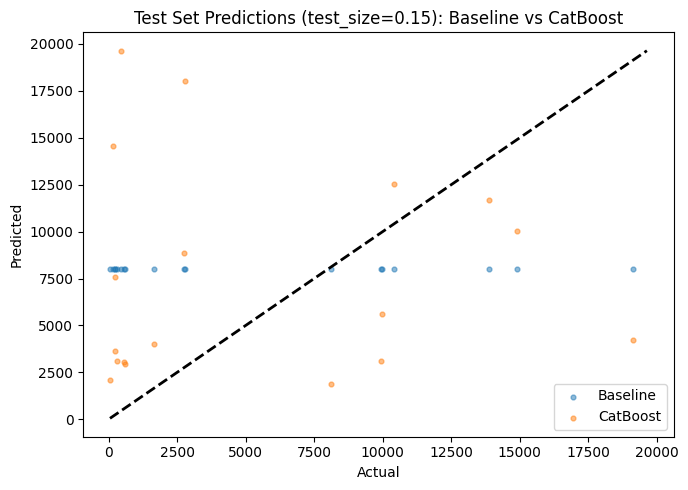

In [4]:
# CatBoost comparison with baseline models for all test sizes (kept simple)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

catboost_params = cb_params(depth=9, l2_leaf_reg=1, bagging_temperature=0)

test_sizes = [0.05, 0.15, 0.25]
cb_results = []
for test_size in test_sizes:
    X_train, X_val, X_test, y_train, y_val, y_test = extract_features_and_target(
        df_copy, drop_missing_target=True, split=True, target=target_name, val_size=0.2, test_size=test_size
    )

    train_pool, val_pool, test_pool = make_pools(
        X_train, X_val, X_test, y_train, y_val, y_test
    )

    cb = CatBoostRegressor(**catboost_params)
    cb.fit(train_pool, eval_set=val_pool, use_best_model=True)
    y_test_pred_cb = cb.predict(test_pool)
    cb_results.append({
        'test_size': test_size,
        'model': 'CatBoost',
        'test_r2': r2_score(y_test, y_test_pred_cb),
        'test_rmse': mean_squared_error(y_test, y_test_pred_cb),
        'test_mae': mean_absolute_error(y_test, y_test_pred_cb),
        'test_brier': brier_pair(y_train, y_test, y_test_pred_cb),
        'y_test_actual': y_test.values,
        'y_test_pred': y_test_pred_cb,
    })

baseline_table = []
for test_size in test_sizes:
    baseline_rows = adv_df[(adv_df['test_size'] == test_size) & (adv_df['model'] == best_row['model'])]
    baseline_row = baseline_rows.iloc[0]
    cb_row = next(r for r in cb_results if r['test_size'] == test_size)
    baseline_table.append({
        'Test Size': test_size,
        'Model': best_row['model'],
        'Type': 'Baseline',
        'Test R2': baseline_row['test_r2'],
        'Test RMSE': baseline_row['test_rmse'],
        'Test MAE': baseline_row['test_mae'],
        'Test Brier': baseline_row.get('test_brier', np.nan),
    })
    baseline_table.append({
        'Test Size': test_size,
        'Model': 'CatBoost',
        'Type': 'CatBoost',
        'Test R2': cb_row['test_r2'],
        'Test RMSE': cb_row['test_rmse'],
        'Test MAE': cb_row['test_mae'],
        'Test Brier': cb_row['test_brier'],
    })

comp_df = pd.DataFrame(baseline_table)
print("\nComparison of Baseline vs CatBoost for all test sizes:")
print(comp_df.to_string(index=False))

# Optional: plot predictions for test_size=0.15
cb_row_015 = next(r for r in cb_results if r['test_size'] == 0.15)
baseline_row_015s = adv_df[(adv_df['test_size'] == 0.15) & (adv_df['model'] == best_row['model'])]

baseline_row_015 = baseline_row_015s.iloc[0]
plot_vs_actual_pairs(
    [
        (baseline_row_015['y_test_actual'], baseline_row_015['y_test_pred'], 'Baseline'),
        (cb_row_015['y_test_actual'], cb_row_015['y_test_pred'], 'CatBoost'),
    ],
    'Test Set Predictions (test_size=0.15): Baseline vs CatBoost',
)

CatBoost (test_size=0.05) Validation: R2=0.1218 RMSE=1060929517.31 MAE=11851.61
CatBoost (test_size=0.05) Test:       R2=0.5482 RMSE=14819501.84 MAE=3421.23
Val Brier=0.3352 | Test Brier=0.2722
Best iteration: 725

Top 20 features by mean |SHAP| (validation set):


,feature,mean_abs_shap,mean_shap
20,tp_injury_whiplash,2288.863901,303.818813
44,injury_severity_score_rss,1893.532432,684.700568
3,location_of_incident,1298.713661,205.145677
40,injury_known_flag,1068.929015,204.394278
50,ph_considered_tp_at_fault_x_injury_sev,631.984696,565.255972
48,vehicle_mobile_x_injury_sev,602.807614,72.211427
42,injury_known_ratio,593.842704,-36.811297
5,vehicle_mobile,528.344399,-56.666305
0,notifier,463.301007,-388.590372
39,injury_count,408.078664,119.610281


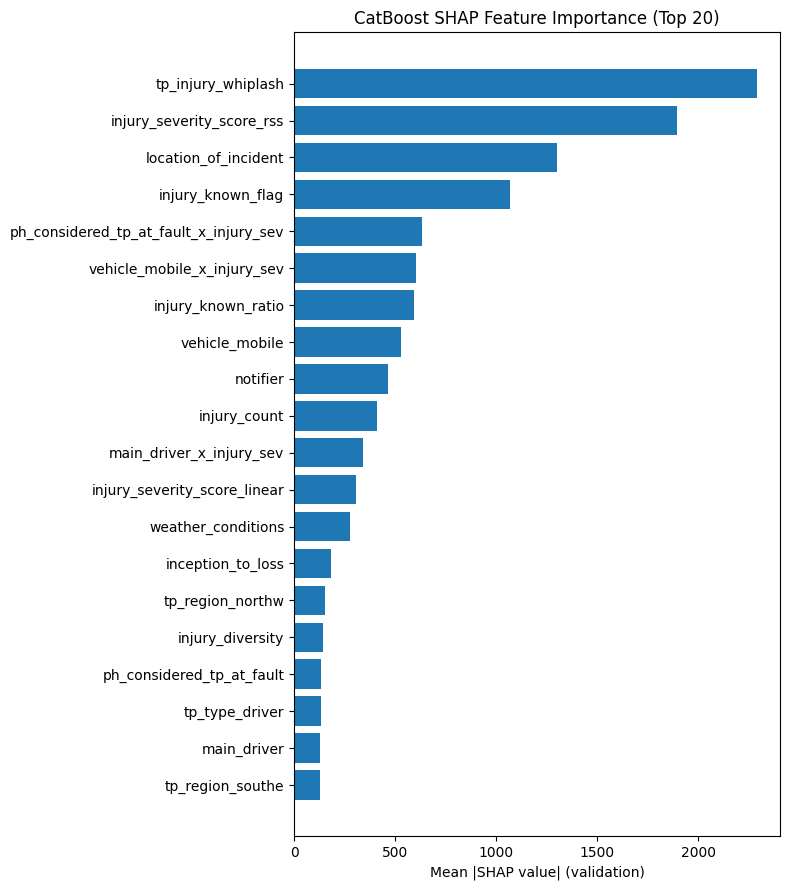

SHAP importance table saved to catboost_shap_importance.csv


In [5]:
# SHAP feature importance for CatBoost (test_size=0.05)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

TEST_SIZE_TARGET = 0.05
VAL_SIZE = 0.3
X_train_cb, X_val_cb, X_test_cb, y_train_cb, y_val_cb, y_test_cb = extract_features_and_target(
    df_copy, drop_missing_target=True, split=True, target=target_name, val_size=VAL_SIZE, test_size=TEST_SIZE_TARGET
)

train_pool_cb, val_pool_cb, test_pool_cb = make_pools(
    X_train_cb, X_val_cb, X_test_cb, y_train_cb, y_val_cb, y_test_cb
)

catboost_params_specific = cb_params(depth=7, iterations=1000)
cb_model = CatBoostRegressor(**catboost_params_specific)
cb_model.fit(train_pool_cb, eval_set=val_pool_cb, use_best_model=True)

# quick metrics
y_val_pred_cb = cb_model.predict(val_pool_cb)
y_test_pred_cb = cb_model.predict(test_pool_cb)
print(f"CatBoost (test_size={TEST_SIZE_TARGET}) Validation: R2={r2_score(y_val_cb, y_val_pred_cb):.4f} "
      f"RMSE={mean_squared_error(y_val_cb, y_val_pred_cb):.2f} MAE={mean_absolute_error(y_val_cb, y_val_pred_cb):.2f}")
print(f"CatBoost (test_size={TEST_SIZE_TARGET}) Test:       R2={r2_score(y_test_cb, y_test_pred_cb):.4f} "
      f"RMSE={mean_squared_error(y_test_cb, y_test_pred_cb):.2f} MAE={mean_absolute_error(y_test_cb, y_test_pred_cb):.2f}")

# Brier for context
print(f"Val Brier={brier_pair(y_train_cb, y_val_cb, y_val_pred_cb):.4f} | Test Brier={brier_pair(y_train_cb, y_test_cb, y_test_pred_cb):.4f}")
print(f"Best iteration: {getattr(cb_model, 'best_iteration_', 'n/a')}")

# SHAP values from CatBoost
shap_vals_val = cb_model.get_feature_importance(val_pool_cb, type='ShapValues')
shap_feature_vals = shap_vals_val[:, :-1]
mean_abs_shap = np.abs(shap_feature_vals).mean(axis=0)
mean_shap = shap_feature_vals.mean(axis=0)

shap_df = pd.DataFrame({
    'feature': X_train_cb.columns,
    'mean_abs_shap': mean_abs_shap,
    'mean_shap': mean_shap,
}).sort_values('mean_abs_shap', ascending=False)

TOP_N = 20
print(f"\nTop {TOP_N} features by mean |SHAP| (validation set):")
display(shap_df.head(TOP_N))

plt.figure(figsize=(8, min(0.4 * TOP_N + 1, 14)))
subset = shap_df.head(TOP_N)[::-1]
plt.barh(subset['feature'], subset['mean_abs_shap'])
plt.xlabel('Mean |SHAP value| (validation)')
plt.title(f'CatBoost SHAP Feature Importance (Top {TOP_N})')
plt.tight_layout()
plt.show()

shap_results_path = 'catboost_shap_importance.csv'
shap_df.to_csv(shap_results_path, index=False)
print(f"SHAP importance table saved to {shap_results_path}")


Top 5 SHAP features: ['tp_injury_whiplash', 'injury_severity_score_rss', 'location_of_incident', 'injury_known_flag', 'ph_considered_tp_at_fault_x_injury_sev']


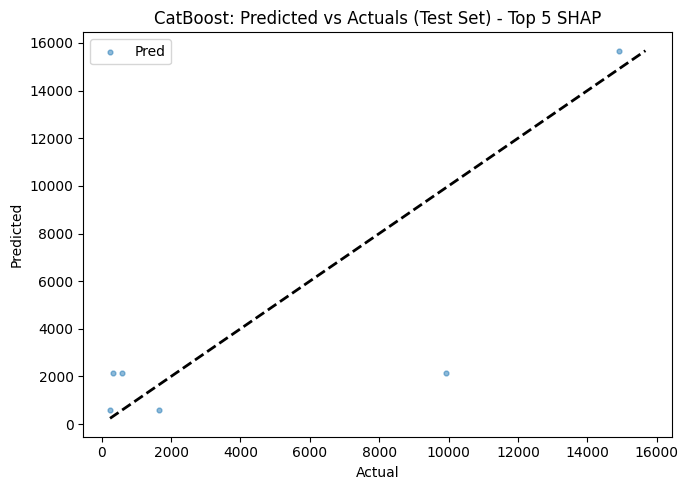


Top 15 SHAP features: ['tp_injury_whiplash', 'injury_severity_score_rss', 'location_of_incident', 'injury_known_flag', 'ph_considered_tp_at_fault_x_injury_sev', 'vehicle_mobile_x_injury_sev', 'injury_known_ratio', 'vehicle_mobile', 'notifier', 'injury_count', 'main_driver_x_injury_sev', 'injury_severity_score_linear', 'weather_conditions', 'inception_to_loss', 'tp_region_northw']


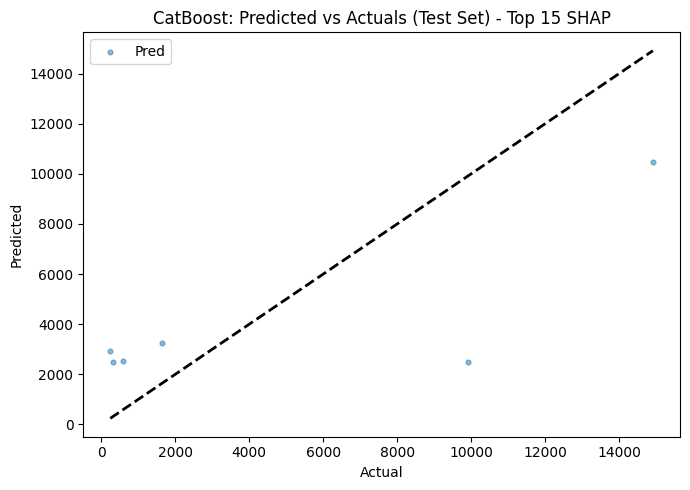


Top 25 SHAP features: ['tp_injury_whiplash', 'injury_severity_score_rss', 'location_of_incident', 'injury_known_flag', 'ph_considered_tp_at_fault_x_injury_sev', 'vehicle_mobile_x_injury_sev', 'injury_known_ratio', 'vehicle_mobile', 'notifier', 'injury_count', 'main_driver_x_injury_sev', 'injury_severity_score_linear', 'weather_conditions', 'inception_to_loss', 'tp_region_northw', 'injury_diversity', 'ph_considered_tp_at_fault', 'tp_type_driver', 'main_driver', 'tp_region_southe', 'tp_injury_unclear', 'tp_injury_nk', 'incident_details_present', 'time_hour', 'tp_type_other']


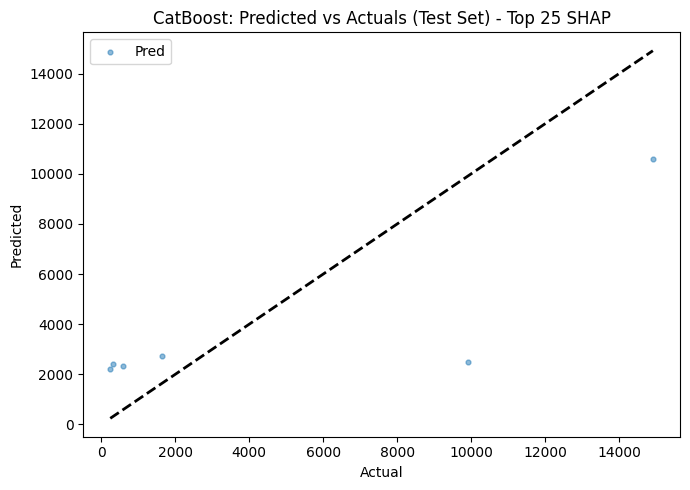


Top 40 SHAP features: ['tp_injury_whiplash', 'injury_severity_score_rss', 'location_of_incident', 'injury_known_flag', 'ph_considered_tp_at_fault_x_injury_sev', 'vehicle_mobile_x_injury_sev', 'injury_known_ratio', 'vehicle_mobile', 'notifier', 'injury_count', 'main_driver_x_injury_sev', 'injury_severity_score_linear', 'weather_conditions', 'inception_to_loss', 'tp_region_northw', 'injury_diversity', 'ph_considered_tp_at_fault', 'tp_type_driver', 'main_driver', 'tp_region_southe', 'tp_injury_unclear', 'tp_injury_nk', 'incident_details_present', 'time_hour', 'tp_type_other', 'days_since_first_loss', 'notification_period', 'injury_details_present', 'tp_type_nk', 'tp_region_eastmid', 'tp_region_outerldn', 'tp_region_eastang', 'tp_type_pass_front', 'injury_unknown_flag', 'tp_injury_traumatic', 'tp_type_pass_back', 'injury_traumatic_flag', 'tp_region_southw', 'tp_region_westmid', 'injury_any_flag']


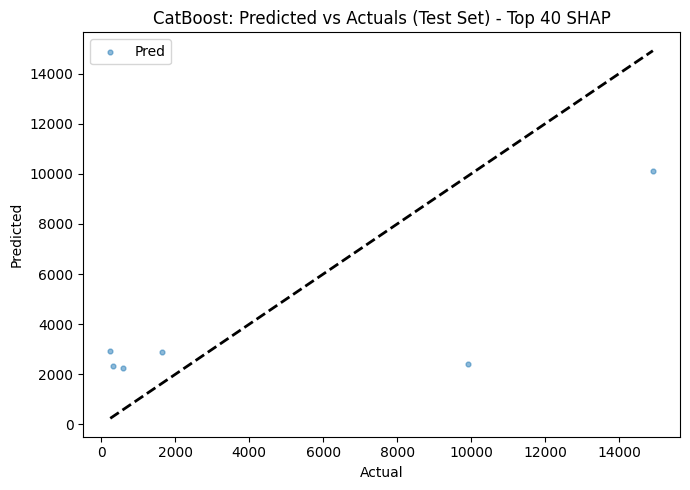


CatBoost Top-N vs Full Feature Set:


,Model,Val R2,Val RMSE,Val MAE,Val Brier,Test R2,Test RMSE,Test MAE,Test Brier,Best Iter
0,CatBoost Top 5,0.100488,1.557412e+09,15793.235358,0.496440,0.653475,1.136723e+07,2218.239943,0.261841,673
1,CatBoost Top 15,0.028767,1.681591e+09,15107.280217,0.549927,0.526860,1.552063e+07,3374.950358,0.280061,411
2,CatBoost Top 25,0.048361,1.647665e+09,15118.398719,0.538733,0.560560,1.441517e+07,3102.011755,0.279423,505
3,CatBoost Top 40,0.031676,1.676554e+09,15168.902858,0.540446,0.516230,1.586933e+07,3317.115208,0.281753,750
4,CatBoost Full,0.058075,1.630847e+09,14759.146998,0.536549,0.584329,1.363546e+07,2881.500919,0.277783,550


In [6]:
# CatBoost: Varying Top-N SHAP features vs Full Feature Set
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

shap_df = pd.read_csv('catboost_shap_importance.csv')
topN_list = [5, 15, 25, 40]

TEST_SIZE_TARGET = 0.05
VAL_SIZE = 0.2
X_train_cb, X_val_cb, X_test_cb, y_train_cb, y_val_cb, y_test_cb = extract_features_and_target(
    df_copy, drop_missing_target=True, split=True, target=target_name, val_size=VAL_SIZE, test_size=TEST_SIZE_TARGET
)

results = []
for topN in topN_list:
    top_features = shap_df.head(topN)['feature'].tolist()
    print(f"\nTop {topN} SHAP features: {top_features}")

    X_train_topN = X_train_cb[top_features].copy()
    X_val_topN = X_val_cb[top_features].copy()
    X_test_topN = X_test_cb[top_features].copy()

    train_pool_topN, val_pool_topN, test_pool_topN = make_pools(
        X_train_topN, X_val_topN, X_test_topN, y_train_cb, y_val_cb, y_test_cb
    )

    catboost_params_comp = cb_params(depth=7)
    cb_topN = CatBoostRegressor(**catboost_params_comp)
    cb_topN.fit(train_pool_topN, eval_set=val_pool_topN, use_best_model=True)

    y_val_pred_topN = cb_topN.predict(val_pool_topN)
    y_test_pred_topN = cb_topN.predict(test_pool_topN)

    results.append({
        'Model': f'CatBoost Top {topN}',
        'Val R2': r2_score(y_val_cb, y_val_pred_topN),
        'Val RMSE': mean_squared_error(y_val_cb, y_val_pred_topN),
        'Val MAE': mean_absolute_error(y_val_cb, y_val_pred_topN),
        'Val Brier': brier_pair(y_train_cb, y_val_cb, y_val_pred_topN),
        'Test R2': r2_score(y_test_cb, y_test_pred_topN),
        'Test RMSE': mean_squared_error(y_test_cb, y_test_pred_topN),
        'Test MAE': mean_absolute_error(y_test_cb, y_test_pred_topN),
        'Test Brier': brier_pair(y_train_cb, y_test_cb, y_test_pred_topN),
        'Best Iter': getattr(cb_topN, 'best_iteration_', 'n/a'),
    })

    plot_pred_vs_actual(y_test_cb, y_test_pred_topN, f'CatBoost: Predicted vs Actuals (Test Set) - Top {topN} SHAP')

# full feature model
train_pool_full, val_pool_full, test_pool_full = make_pools(
    X_train_cb, X_val_cb, X_test_cb, y_train_cb, y_val_cb, y_test_cb
)

cb_full = CatBoostRegressor(**catboost_params_comp)
cb_full.fit(train_pool_full, eval_set=val_pool_full, use_best_model=True)

y_val_pred_full = cb_full.predict(val_pool_full)
y_test_pred_full = cb_full.predict(test_pool_full)

results.append({
    'Model': 'CatBoost Full',
    'Val R2': r2_score(y_val_cb, y_val_pred_full),
    'Val RMSE': mean_squared_error(y_val_cb, y_val_pred_full),
    'Val MAE': mean_absolute_error(y_val_cb, y_val_pred_full),
    'Val Brier': brier_pair(y_train_cb, y_val_cb, y_val_pred_full),
    'Test R2': r2_score(y_test_cb, y_test_pred_full),
    'Test RMSE': mean_squared_error(y_test_cb, y_test_pred_full),
    'Test MAE': mean_absolute_error(y_test_cb, y_test_pred_full),
    'Test Brier': brier_pair(y_train_cb, y_test_cb, y_test_pred_full),
    'Best Iter': getattr(cb_full, 'best_iteration_', 'n/a'),
})

comp_df = pd.DataFrame(results)
print("\nCatBoost Top-N vs Full Feature Set:")
display(comp_df)

Using top-40 features (first few): ['tp_injury_whiplash', 'injury_severity_score_rss', 'location_of_incident', 'injury_known_flag', 'ph_considered_tp_at_fault_x_injury_sev', 'vehicle_mobile_x_injury_sev', 'injury_known_ratio', 'vehicle_mobile'] ...


new best r2=0.0798 depth=5 lr=0.01 l2=1.0
new best r2=0.0846 depth=5 lr=0.01 l2=3.0
new best r2=0.0846 depth=5 lr=0.01 l2=3.0
new best r2=0.0882 depth=7 lr=0.03 l2=3.0
new best r2=0.0882 depth=7 lr=0.03 l2=3.0
 trial  depth   lr  l2   val_r2  best_iter
     8      7 0.03 3.0 0.088201        307
     2      5 0.01 3.0 0.084592        911
     1      5 0.01 1.0 0.079759        886
     3      5 0.03 1.0 0.070125        258
     4      5 0.03 3.0 0.064136        465
     5      7 0.01 1.0 0.034396        654
     6      7 0.01 3.0 0.031676        750
     7      7 0.03 1.0 0.026380        553
     9      9 0.01 1.0 0.010014        779
    10      9 0.01 3.0 0.004629        652

Best params: {'depth': 7, 'learning_rate': 0.03, 'l2_leaf_reg': 3.0} best_iter: 307
 trial  depth   lr  l2   val_r2  best_iter
     8      7 0.03 3.0 0.088201        307
     2      5 0.01 3.0 0.084592        911
     1      5 0.01 1.0 0.079759        886
     3      5 0.03 1.0 0.070125        258
     4      5 0.0

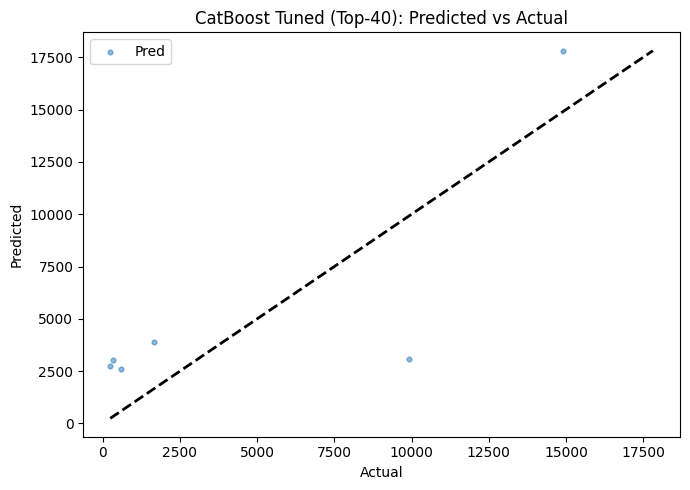

In [7]:
# Fine-tune CatBoost using Top-40 SHAP features (simple grid search)
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

shap_df = pd.read_csv('catboost_shap_importance.csv')
top_features_40 = shap_df.head(40)['feature'].tolist()
print('Using top-40 features (first few):', top_features_40[:8], '...')

TEST_SIZE_TARGET = 0.05
VAL_SIZE = 0.2
X_train_cb, X_val_cb, X_test_cb, y_train_cb, y_val_cb, y_test_cb = extract_features_and_target(
    df_copy, drop_missing_target=True, split=True, target=target_name, val_size=VAL_SIZE, test_size=TEST_SIZE_TARGET
)

X_train_40 = X_train_cb[top_features_40].copy()
X_val_40 = X_val_cb[top_features_40].copy()
X_test_40 = X_test_cb[top_features_40].copy()

train_pool_40, val_pool_40, test_pool_40 = make_pools(
    X_train_40, X_val_40, X_test_40, y_train_cb, y_val_cb, y_test_cb
)

depth_list = [5, 7, 9]
lr_list = [0.01, 0.03]
l2_list = [1.0, 3.0]

best_r2 = -1e9
best_params = None
best_model = None
rows = []
trial = 0
for d in depth_list:
    for lr in lr_list:
        for l2 in l2_list:
            trial += 1
            params = {
                'loss_function': 'MAE',
                'eval_metric': 'R2',
                'random_seed': 42,
                'iterations': 2000,
                'early_stopping_rounds': 200,
                'verbose': False,
                'depth': d,
                'learning_rate': lr,
                'l2_leaf_reg': l2,
            }
            model = CatBoostRegressor(**params)
            model.fit(train_pool_40, eval_set=val_pool_40, use_best_model=True)
            r2 = r2_score(y_val_cb, model.predict(val_pool_40))
            rows.append({'trial': trial, 'depth': d, 'lr': lr, 'l2': l2, 'val_r2': r2, 'best_iter': getattr(model, 'best_iteration_', None)})
            if r2 > best_r2:
                best_r2 = r2
                best_params = params
                best_model = model
                print(f"new best r2={r2:.4f} depth={d} lr={lr} l2={l2}")

trials_df = pd.DataFrame(rows).sort_values('val_r2', ascending=False)
print(trials_df.head(10).to_string(index=False))
print('\nBest params:', {k: best_params[k] for k in ['depth','learning_rate','l2_leaf_reg']}, 'best_iter:', getattr(best_model, 'best_iteration_', None))

# retrain on train+val (simple concat)
X_trainval_40 = pd.concat([X_train_40, X_val_40], axis=0)
y_trainval = pd.concat([y_train_cb, y_val_cb], axis=0)

# quick cat handling for combined set
cat_cols_tv = [c for c in X_trainval_40.columns if (X_trainval_40[c].dtype == 'object' or str(X_trainval_40[c].dtype).startswith('category'))]
for c in cat_cols_tv:
    X_trainval_40[c] = X_trainval_40[c].astype(str)
cat_idx_tv = [X_trainval_40.columns.get_loc(c) for c in cat_cols_tv]
trainval_pool_40 = Pool(X_trainval_40, y_trainval, cat_features=cat_idx_tv)

final_model = CatBoostRegressor(**best_params)
final_model.fit(trainval_pool_40, eval_set=val_pool_40, use_best_model=False)
y_test_pred = final_model.predict(test_pool_40)
print(f"\nFinal Test: R2={r2_score(y_test_cb, y_test_pred):.4f} RMSE={mean_squared_error(y_test_cb, y_test_pred):.2f} MAE={mean_absolute_error(y_test_cb, y_test_pred):.2f} Brier={brier_pair(y_train_cb, y_test_cb, y_test_pred):.4f}")

plot_pred_vs_actual(y_test_cb, y_test_pred, 'CatBoost Tuned (Top-40): Predicted vs Actual')

In [ ]:
# Frequentist uncertainty via 20 random starts (Top-40 features, best params)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

shap_df = pd.read_csv('catboost_shap_importance.csv')
top_features_40 = shap_df.head(40)['feature'].tolist()

TEST_SIZE_TARGET = 0.05
VAL_SIZE = 0.2
X_train_cb, X_val_cb, X_test_cb, y_train_cb, y_val_cb, y_test_cb = extract_features_and_target(
    df_copy, drop_missing_target=True, split=True, target=target_name, val_size=VAL_SIZE, test_size=TEST_SIZE_TARGET
)

X_train_40 = X_train_cb[top_features_40].copy()
X_val_40 = X_val_cb[top_features_40].copy()
X_test_40 = X_test_cb[top_features_40].copy()

train_pool_40, val_pool_40, test_pool_40 = make_pools(
    X_train_40, X_val_40, X_test_40, y_train_cb, y_val_cb, y_test_cb
)

best_params = dict(
    loss_function='MAE',
    depth=9,
    learning_rate=0.01,
    iterations=1000,
    random_seed=42,
    eval_metric='R2',
    verbose=False,
    l2_leaf_reg=1,
    bagging_temperature=0,
    early_stopping_rounds=200,
)

n_models = 20
rng = np.random.default_rng(2025)
seeds = [int(s) for s in rng.integers(0, 2**31 - 1, size=n_models)]
preds = []
models = []

n_train = X_train_40.shape[0]
for i, seed in enumerate(seeds, start=1):
    boot_idx = rng.integers(0, n_train, size=n_train)
    X_train_boot = X_train_40.iloc[boot_idx].copy()
    y_train_boot = y_train_cb.iloc[boot_idx].copy()
    # light cat handling for boot sample
    boot_cat_cols = [c for c in X_train_boot.columns if (X_train_boot[c].dtype == 'object' or str(X_train_boot[c].dtype).startswith('category'))]
    for c in boot_cat_cols:
        X_train_boot[c] = X_train_boot[c].astype(str)
    boot_cat_idx = [X_train_boot.columns.get_loc(c) for c in boot_cat_cols]
    train_pool_boot = Pool(X_train_boot, y_train_boot, cat_features=boot_cat_idx)

    params = {**best_params, 'random_seed': int(seed)}
    cb = CatBoostRegressor(**params)
    cb.fit(train_pool_boot, eval_set=val_pool_40, use_best_model=True)
    preds.append(cb.predict(test_pool_40))
    models.append(cb)

preds = np.vstack(preds)
pred_mean = preds.mean(axis=0)
pred_p05 = np.percentile(preds, 5, axis=0)
pred_p95 = np.percentile(preds, 95, axis=0)

print(f"Test metrics (ensemble mean): R2={r2_score(y_test_cb, pred_mean):.4f} "
      f"RMSE={mean_squared_error(y_test_cb, pred_mean):.2f} MAE={mean_absolute_error(y_test_cb, pred_mean):.2f}")
print(f"Test Brier (ensemble mean): {brier_pair(y_train_cb, y_test_cb, pred_mean):.4f}")
coverage_90 = np.mean((y_test_cb.values >= pred_p05) & (y_test_cb.values <= pred_p95))
print(f"90% interval coverage: {coverage_90*100:.1f}%")

interval_df = pd.DataFrame({
    'actual': y_test_cb.values,
    'pred_mean': pred_mean,
    'p05': pred_p05,
    'p95': pred_p95,
})
interval_df.to_csv('catboost_top40_ensemble_intervals.csv', index=False)
print('Saved intervals to catboost_top40_ensemble_intervals.csv')

plot_pred_vs_actual(y_test_cb, pred_mean, 'CatBoost (Top-40, best params) — Mean prediction vs Actual')
plot_intervals(pred_mean, pred_p05, pred_p95, y_test_cb, 'CatBoost (Top-40, best params) — 90% prediction intervals (test)')

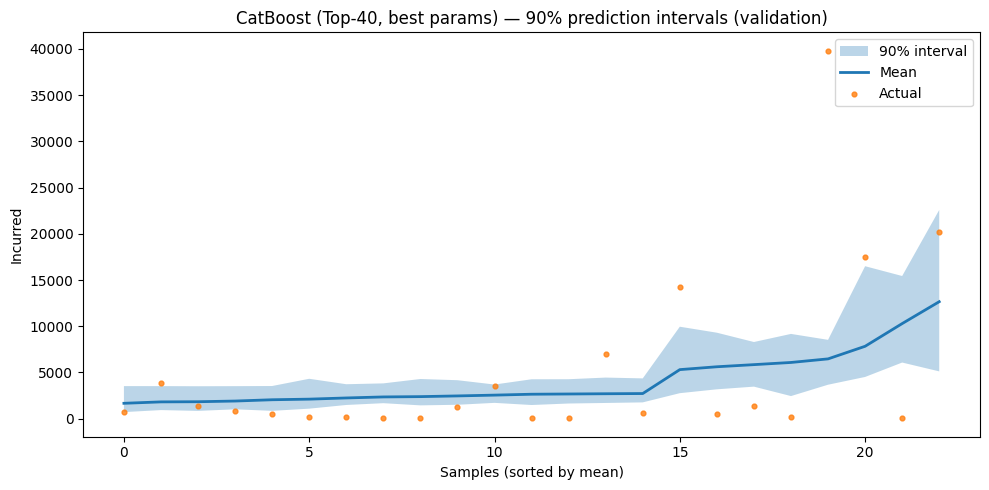

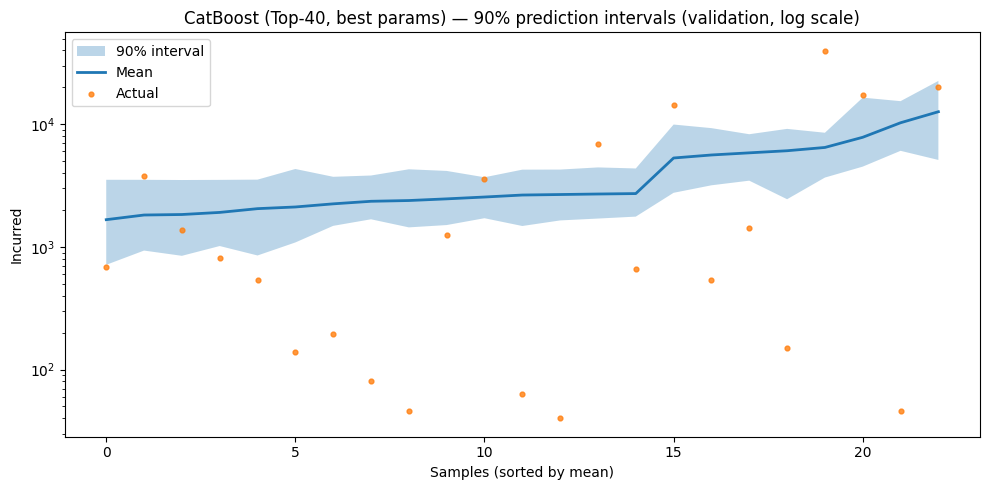

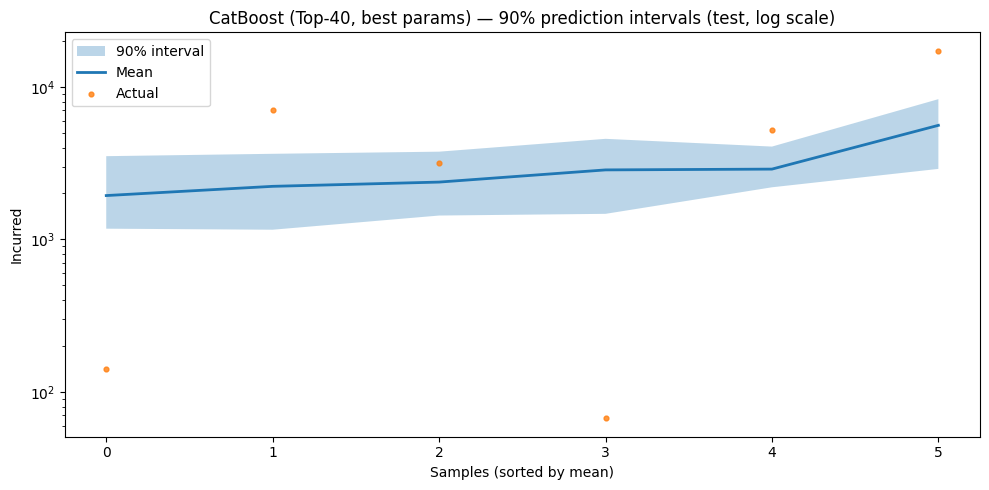

In [ ]:
# Compute ensemble predictions for validation data (simple)
val_preds = []
for cb in models:
    val_preds.append(cb.predict(val_pool_40))
val_preds = np.vstack(val_preds)
val_pred_mean = val_preds.mean(axis=0)
val_pred_p05 = np.percentile(val_preds, 5, axis=0)
val_pred_p95 = np.percentile(val_preds, 95, axis=0)

plot_intervals(val_pred_mean, val_pred_p05, val_pred_p95, y_val_cb, 'CatBoost (Top-40, best params) — 90% prediction intervals (validation)')
plot_intervals(val_pred_mean, val_pred_p05, val_pred_p95, y_val_cb, 'CatBoost (Top-40, best params) — 90% prediction intervals (validation, log scale)', log_scale=True)
plot_intervals(pred_mean, pred_p05, pred_p95, y_test_cb, 'CatBoost (Top-40, best params) — 90% prediction intervals (test, log scale)', log_scale=True)

# Bayesian uncertainty quantification (UQ) with PyMC

This section adds a fully Bayesian alternative to the frequentist ensemble in the previous cell.

- We model log(1 + incurred) as a Normal around a linear predictor of the Top-40 SHAP features.
- Priors on coefficients and noise naturally propagate uncertainty to posterior predictive intervals.
- This is fast, interpretable, and a solid baseline for Bayesian UQ. If you need richer nonlinearity, you can later swap the linear mean for BART in PyMC.

Notes
- Runtime depends on data size; defaults below aim to be reasonable on a laptop. Increase draws if you need tighter Monte Carlo error.
- We one-hot encode categoricals and standardize features for stable sampling.